Learn how to group similar data points without labels using KMeans Clustering.
Steps
•	Load dataset.
•	Explore data (scatterplots of Age vs Income, Spending Score distribution).
•	Apply KMeans Clustering → group customers into 3–5 clusters.
•	Visualize clusters with Matplotlib/Seaborn.
•	Task: For a new customer (Age=30, Income=50k, Spending=60), predict which cluster they belong to


In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler  #feature scaling
from sklearn.cluster import KMeans                #clustering


In [128]:
df=pd.read_csv('mall.csv')
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [129]:
df.info()                    #column types and missing values
df.describe()               # mean,std,min,max
df.shape                      #dataset size (rows, columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB


(15079, 5)

In [130]:
df=df.drop(columns=['Customer ID','Gender'])         #delete unnecessary columns


In [131]:
print(df.columns)          #display column names

Index(['Age', 'Annual Income', 'Spending Score'], dtype='object')


In [132]:
#Select features for clustering 
df = df[['Age','Annual Income','Spending Score']]
X = df.values               #convert to numpy array

Explore data - scatter and histogram

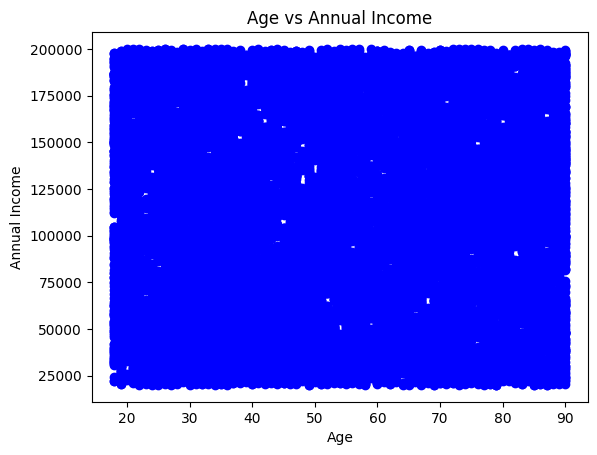

In [133]:
plt.scatter(X[:,0], X[:,1], color='blue')   # Scatterplot: Age vs Annual Income
plt.title('Age vs Annual Income')            #blue points shows customers distribution
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.show()

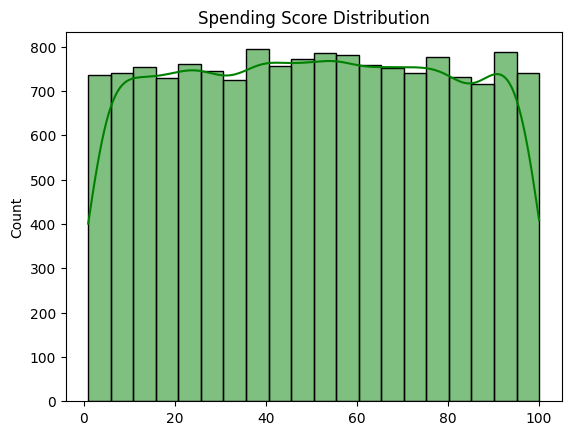

In [134]:
# Histogram Spending Score distribution  #Data ko pattern visualization
sns.histplot(X[:,2], bins=20, kde=True, color='green')
plt.title('Spending Score Distribution')
plt.show()

In [ ]:
# Scale features for better clustering (mean=0, std=1)
scaler = StandardScaler()    #values can be negative or greater than 1 unline MinMax scaler
X_scaled = scaler.fit_transform(X)

In [136]:
#Apply KMeans Clustering
k = 4   # number of clusters (can try 3,4,5)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)                   #assign cluster labels

In [141]:
# Add cluster labels to DataFrame for reference
df['Cluster'] = clusters
df.head()

,Age,Annual Income,Spending Score,Cluster
0,30,151479,89,1
1,58,185088,95,2
2,62,70912,76,3
3,23,55460,57,3
4,24,153752,76,1


Visualize Clusters

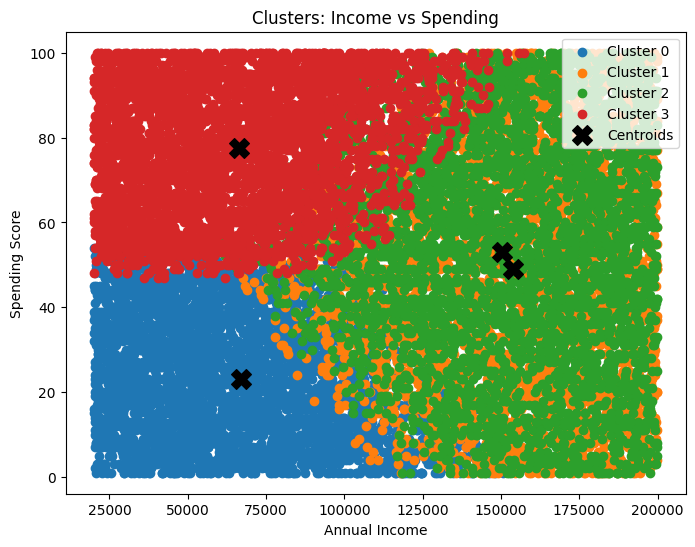

In [138]:
# Annual Income vs Spending Score
plt.figure(figsize=(8,6))
for i in range(k):
    plt.scatter(df[df['Cluster']==i]['Annual Income'], df[df['Cluster']==i]['Spending Score'], label=f'Cluster {i}')
# Centroids position shows avg income and spending of each cluster
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:,1], centers[:,2], c='black', s=200, marker='X', label='Centroids')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Clusters: Income vs Spending')
plt.legend()
plt.show()

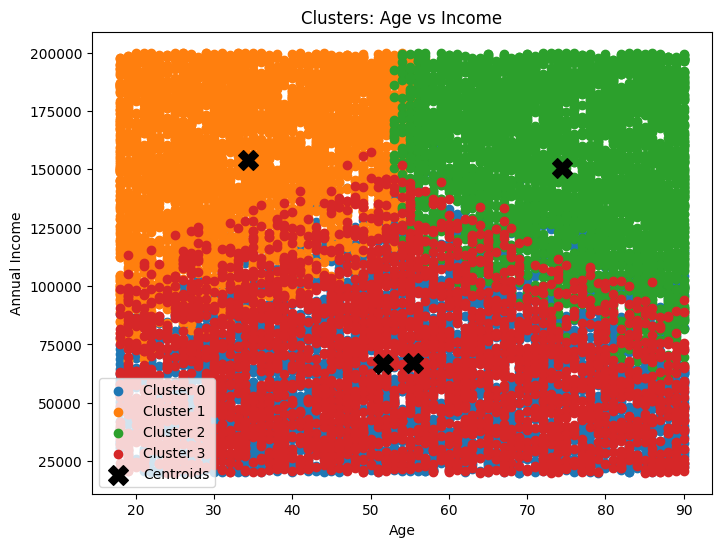

In [139]:
# Age vs Annual Income
plt.figure(figsize=(8,6))
for i in range(k):
    plt.scatter(df[df['Cluster']==i]['Age'], df[df['Cluster']==i]['Annual Income'], label=f'Cluster {i}')
plt.scatter(centers[:,0], centers[:,1], c='black', s=200, marker='X', label='Centroids')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.title('Clusters: Age vs Income')
plt.legend()
plt.show()


In [140]:
# New customer: Age=30, Income=50000, Spending=60
new_customer = np.array([[30, 50000, 60]])   # NumPy array
new_scaled = scaler.transform(new_customer)   # Scale features= assign nearest centroid
pred_cluster = kmeans.predict(new_scaled)
print(f"New customer belongs to Cluster: {pred_cluster[0]}")

New customer belongs to Cluster: 3
